# 02 — Data Preprocessing
### TCGA-BRCA Cancer Survival ML Pipeline

**Goal:** Transform raw GDC clinical TSV files into a clean, model-ready feature matrix.

**Input files:**
- `data/raw/clinical.tsv` — demographics, diagnosis, staging, treatments
- `data/raw/follow_up.tsv` — menopause status, disease response
- `data/raw/pathology_detail.tsv` — lymph node counts

**Output:** `data/processed/brca_features.csv` — one row per patient, ready for modeling

---
**Pipeline Steps:**
1. Load & fix GDC missing values
2. Deduplicate clinical file (multiple treatment rows → one row per patient)
3. Engineer survival target (`high_risk`)
4. Engineer all features
5. Merge follow-up and pathology data
6. Final cleaning & export

## 0. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_DIR     = 'data/raw/'
PROC_DIR    = 'data/processed/'
PLOT_DIR    = 'outputs/plots/'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# Survival threshold: 5 years in days
SURVIVAL_THRESHOLD_DAYS = 1825

print('Libraries loaded successfully.')
print(f'Survival threshold: {SURVIVAL_THRESHOLD_DAYS} days (5 years)')

Libraries loaded successfully.
Survival threshold: 1825 days (5 years)


## 1. Load Raw Data & Fix Missing Values

> **GDC Note:** The GDC portal encodes missing/not-applicable values as the string `'--` (with a leading single quote). We replace all these with `NaN` so pandas handles them correctly.

In [2]:
# Load all three files
clinical  = pd.read_csv(RAW_DIR + 'clinical.tsv',         sep='\t', low_memory=False)
follow_up = pd.read_csv(RAW_DIR + 'follow_up.tsv',        sep='\t', low_memory=False)
pathology = pd.read_csv(RAW_DIR + 'pathology_detail.tsv', sep='\t', low_memory=False)

# Replace GDC's missing value marker with NaN
GDC_NULL = "'--"
for df in [clinical, follow_up, pathology]:
    df.replace(GDC_NULL, np.nan, inplace=True)

print(f'clinical.tsv  : {len(clinical):,} rows, {clinical["cases.case_id"].nunique():,} unique patients')
print(f'follow_up.tsv : {len(follow_up):,} rows, {follow_up["cases.case_id"].nunique():,} unique patients')
print(f'pathology.tsv : {len(pathology):,} rows, {pathology["cases.case_id"].nunique():,} unique patients')

clinical.tsv  : 5,546 rows, 1,098 unique patients
follow_up.tsv : 9,427 rows, 1,096 unique patients
pathology.tsv : 1,096 rows, 1,096 unique patients


## 2. Deduplicate Clinical File

The clinical file has **multiple rows per patient** — one row per treatment received.  
Demographic and diagnosis columns repeat identically across all rows for the same patient.  
Treatment columns differ per row — we'll aggregate them into a single feature.

**Strategy:**
- Take the first row for all non-treatment columns (they're identical across rows)
- Aggregate treatment types into a pipe-separated string per patient, then one-hot encode

In [3]:
# --- Step 2a: Aggregate treatment types per patient ---
# Collect all treatment types for each patient as a set
treatment_agg = (
    clinical
    .dropna(subset=['treatments.treatment_type'])
    .groupby('cases.case_id')['treatments.treatment_type']
    .apply(lambda x: '|'.join(sorted(x.unique())))
    .reset_index()
    .rename(columns={'treatments.treatment_type': 'treatment_types_all'})
)

print(f'Patients with at least one treatment recorded: {len(treatment_agg):,}')
print('\nSample treatment aggregation:')
print(treatment_agg.head(5).to_string(index=False))

Patients with at least one treatment recorded: 1,097

Sample treatment aggregation:
                       cases.case_id                                                                                treatment_types_all
001cef41-ff86-4d3f-a140-a647ac4b10a1                                                Hormone Therapy|Radiation Therapy, NOS|Surgery, NOS
0045349c-69d9-4306-a403-c9c1fa836644                                                                                       Surgery, NOS
00807dae-9f4a-4fd1-aac2-82eb11bf2afb Bisphosphonate Therapy|Chemotherapy|Radiation Therapy, NOS|Surgery, NOS|Targeted Molecular Therapy
00a2d166-78c9-4687-a195-3d6315c27574                                    Pharmaceutical Therapy, NOS|Radiation Therapy, NOS|Surgery, NOS
00b11ca8-8540-4a3d-b602-ec754b00230b       Chemotherapy|Hormone Therapy|Pharmaceutical Therapy, NOS|Radiation Therapy, NOS|Surgery, NOS


In [4]:
# --- Step 2b: Keep only one row per patient (first row — non-treatment cols are identical) ---
# Drop treatment columns before deduplication to avoid confusion
treatment_cols = [c for c in clinical.columns if c.startswith('treatments.')]
clinical_dedup = (
    clinical
    .drop(columns=treatment_cols)
    .drop_duplicates(subset='cases.case_id', keep='first')
    .reset_index(drop=True)
)

# Merge aggregated treatments back in
clinical_dedup = clinical_dedup.merge(treatment_agg, on='cases.case_id', how='left')

print(f'After deduplication: {len(clinical_dedup):,} rows (one per patient)')
assert len(clinical_dedup) == clinical['cases.case_id'].nunique(), 'Deduplication mismatch!'
print('✓ Row count matches unique patient count.')

After deduplication: 1,098 rows (one per patient)
✓ Row count matches unique patient count.


## 3. Engineer Survival Target Variable

We create two outputs:
- **`survival_time`** — days from diagnosis to death or last follow-up (for Kaplan-Meier curves)
- **`event`** — 1 if the patient died, 0 if censored/alive (for Kaplan-Meier)
- **`high_risk`** — **classification target** — 1 if patient died within 5 years, 0 otherwise

In [5]:
df = clinical_dedup.copy()

# Convert to numeric (some values may be string floats)
df['days_to_death']        = pd.to_numeric(df['demographic.days_to_death'],         errors='coerce')
df['days_to_last_followup']= pd.to_numeric(df['diagnoses.days_to_last_follow_up'],  errors='coerce')

# Survival time: use days_to_death if available, else days_to_last_followup
df['survival_time'] = df['days_to_death'].combine_first(df['days_to_last_followup'])

# Event flag: 1 = died, 0 = alive / lost to follow-up (censored)
df['event'] = (df['demographic.vital_status'] == 'Dead').astype(int)

# HIGH RISK TARGET: died AND within 5 years
df['high_risk'] = ((df['event'] == 1) & (df['survival_time'] <= SURVIVAL_THRESHOLD_DAYS)).astype(int)

# Drop rows where we have no survival time at all
n_before = len(df)
df = df.dropna(subset=['survival_time'])
n_dropped = n_before - len(df)

print(f'Patients after dropping missing survival_time: {len(df):,} (dropped {n_dropped})')
print(f'\nTarget distribution (high_risk):')
print(df['high_risk'].value_counts().rename({0: 'Low Risk (0)', 1: 'High Risk (1)'}))  
print(f'\nHigh-risk rate: {df["high_risk"].mean()*100:.1f}%')

# Quick sanity check
print(f'\nSurvival time range: {df["survival_time"].min():.0f} – {df["survival_time"].max():.0f} days')
print(f'Total deaths: {df["event"].sum()} | Total alive: {(df["event"]==0).sum()}')

Patients after dropping missing survival_time: 1,036 (dropped 62)

Target distribution (high_risk):
high_risk
Low Risk (0)     934
High Risk (1)    102
Name: count, dtype: int64

High-risk rate: 9.8%

Survival time range: -7 – 8556 days
Total deaths: 152 | Total alive: 884


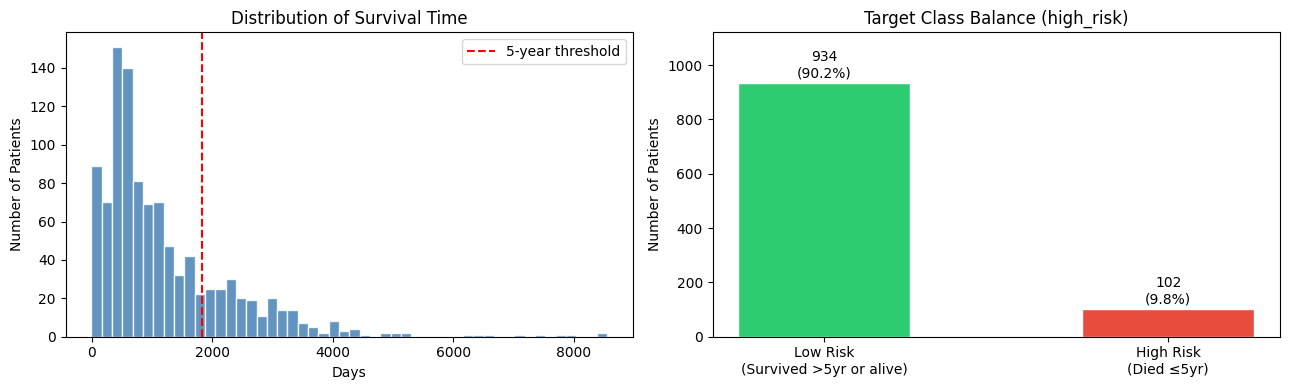

Plot saved to outputs/plots/target_distribution.png


In [6]:
# --- Visualize survival time distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of survival times
axes[0].hist(df['survival_time'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(SURVIVAL_THRESHOLD_DAYS, color='red', linestyle='--', linewidth=1.5, label='5-year threshold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Distribution of Survival Time')
axes[0].legend()

# Class balance
labels = ['Low Risk\n(Survived >5yr or alive)', 'High Risk\n(Died ≤5yr)']
counts = df['high_risk'].value_counts().sort_index().values
colors = ['#2ecc71', '#e74c3c']
bars = axes[1].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Number of Patients')
axes[1].set_title('Target Class Balance (high_risk)')
axes[1].set_ylim(0, max(counts) * 1.2)

plt.tight_layout()
plt.savefig(PLOT_DIR + 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/target_distribution.png')

## 4. Feature Engineering

We'll engineer the following features from the clinical data:

| Feature | Source column | Engineering |
|---|---|---|
| `age_at_diagnosis` | `diagnoses.age_at_diagnosis` | Convert days → years |
| `stage_encoded` | `diagnoses.ajcc_pathologic_stage` | Ordinal: Stage I=1 … IV=4 |
| `race_*` | `demographic.race` | One-hot (white, black, asian, other) |
| `prior_malignancy` | `diagnoses.prior_malignancy` | Binary: yes=1, no=0 |
| `subtype_*` | `diagnoses.primary_diagnosis` | One-hot (top 4 subtypes + other) |
| `treat_*` | `treatment_types_all` | Binary flags per treatment modality |

In [7]:
# ============================================================
# FEATURE 1: Age at Diagnosis (days → years)
# ============================================================
df['age_at_diagnosis'] = pd.to_numeric(df['diagnoses.age_at_diagnosis'], errors='coerce') / 365.25

print('Age at diagnosis (years):')
print(df['age_at_diagnosis'].describe().round(1))

Age at diagnosis (years):
count    1016.0
mean       59.1
std        13.1
min        26.9
25%        49.4
50%        59.0
75%        67.9
max        90.0
Name: age_at_diagnosis, dtype: float64


In [8]:
# ============================================================
# FEATURE 2: AJCC Pathologic Stage → Ordinal Encoding
# ============================================================
# Map stage strings to numeric values
# Stage 0 / 0is = 0 (in-situ), Stage I variants = 1, II = 2, III = 3, IV = 4
STAGE_MAP = {
    'Stage 0':    0, 'Stage 0is': 0,
    'Stage I':    1, 'Stage IA':  1, 'Stage IB': 1,
    'Stage II':   2, 'Stage IIA': 2, 'Stage IIB': 2,
    'Stage III':  3, 'Stage IIIA': 3, 'Stage IIIB': 3, 'Stage IIIC': 3,
    'Stage IV':   4,
    'Stage X':    np.nan  # Unknown/unclassifiable — will be imputed
}

df['stage_encoded'] = df['diagnoses.ajcc_pathologic_stage'].map(STAGE_MAP)

print('Stage encoding distribution:')
stage_summary = df.groupby('stage_encoded', dropna=False)['cases.case_id'].count()
print(stage_summary.rename('patient_count'))

Stage encoding distribution:
stage_encoded
1.0    168
2.0    574
3.0    217
4.0     18
NaN     59
Name: patient_count, dtype: int64


In [9]:
# ============================================================
# FEATURE 3: Race → One-Hot Encoding
# ============================================================
# Simplify: white | black_or_african_american | asian | other/not_reported
def map_race(val):
    if pd.isna(val) or val == 'not reported':
        return 'other'
    if val == 'white':
        return 'white'
    if val == 'black or african american':
        return 'black'
    if val == 'asian':
        return 'asian'
    return 'other'

df['race_clean'] = df['demographic.race'].apply(map_race)
race_dummies = pd.get_dummies(df['race_clean'], prefix='race').astype(int)
df = pd.concat([df, race_dummies], axis=1)

print('Race feature counts:')
print(race_dummies.sum())

Race feature counts:
race_asian     60
race_black    170
race_other     86
race_white    720
dtype: int64


In [10]:
# ============================================================
# FEATURE 4: Prior Malignancy → Binary
# ============================================================
def map_prior_malignancy(val):
    if pd.isna(val) or val == 'not reported':
        return np.nan
    if val == 'yes':
        return 1
    return 0  # 'no'

df['prior_malignancy'] = df['diagnoses.prior_malignancy'].apply(map_prior_malignancy)

print('Prior malignancy distribution:')
print(df['prior_malignancy'].value_counts(dropna=False).rename({0.0: 'No (0)', 1.0: 'Yes (1)'}))

Prior malignancy distribution:
prior_malignancy
No (0)     970
NaN         50
Yes (1)     16
Name: count, dtype: int64


In [11]:
# ============================================================
# FEATURE 5: Primary Diagnosis Subtype → One-Hot (Top 4 + Other)
# ============================================================
TOP_SUBTYPES = [
    'Infiltrating duct carcinoma, NOS',
    'Lobular carcinoma, NOS',
    'Infiltrating duct and lobular carcinoma',
    'Metaplastic carcinoma, NOS'
]

def map_subtype(val):
    if pd.isna(val) or val == 'Not Reported':
        return 'other_subtype'
    if val in TOP_SUBTYPES:
        # Shorten names for cleaner column names
        return {
            'Infiltrating duct carcinoma, NOS':          'IDC',
            'Lobular carcinoma, NOS':                    'LC',
            'Infiltrating duct and lobular carcinoma':   'IDC_LC',
            'Metaplastic carcinoma, NOS':                'metaplastic'
        }[val]
    return 'other_subtype'

df['subtype_clean'] = df['diagnoses.primary_diagnosis'].apply(map_subtype)
subtype_dummies = pd.get_dummies(df['subtype_clean'], prefix='subtype').astype(int)
df = pd.concat([df, subtype_dummies], axis=1)

print('Cancer subtype feature counts:')
print(subtype_dummies.sum())

Cancer subtype feature counts:
subtype_IDC              735
subtype_IDC_LC            27
subtype_LC               182
subtype_metaplastic       13
subtype_other_subtype     79
dtype: int64


In [12]:
# ============================================================
# FEATURE 6: Treatment Modalities → Binary Flags
# ============================================================
# Each patient has a pipe-separated string of all treatments they received
# We create binary flags: did this patient receive treatment X at any point?
TREATMENT_FLAGS = {
    'treat_chemotherapy':  ['Chemotherapy'],
    'treat_surgery':       ['Surgery, NOS'],
    'treat_radiation':     ['Radiation Therapy, NOS', 'Radiation, External Beam'],
    'treat_hormone':       ['Hormone Therapy'],
    'treat_targeted':      ['Targeted Molecular Therapy', 'Pharmaceutical Therapy, NOS'],
    'treat_immunotherapy': ['Immunotherapy (Including Vaccines)']
}

def has_treatment(treatment_str, keywords):
    """Return 1 if any keyword appears in the patient's treatment string."""
    if pd.isna(treatment_str):
        return 0
    return int(any(kw in treatment_str for kw in keywords))

for col_name, keywords in TREATMENT_FLAGS.items():
    df[col_name] = df['treatment_types_all'].apply(lambda x: has_treatment(x, keywords))

print('Treatment flag distribution:')
treat_cols = list(TREATMENT_FLAGS.keys())
print(df[treat_cols].sum().sort_values(ascending=False))

Treatment flag distribution:
treat_surgery          1035
treat_radiation         961
treat_chemotherapy      548
treat_hormone           484
treat_targeted          336
treat_immunotherapy      25
dtype: int64


## 5. Merge Follow-Up & Pathology Features

- **Follow-up:** `menopause_status` (one row per patient — take most informative value)
- **Pathology:** `lymph_nodes_positive` (one row per patient)

In [13]:
# ============================================================
# FEATURE 7: Menopause Status (from follow_up.tsv)
# ============================================================
# follow_up has multiple rows per patient; we take the most informative value
# Priority: Postmenopausal > Premenopausal > Perimenopausal > Unknown
MENO_PRIORITY = {'Postmenopausal': 0, 'Premenopausal': 1, 'Perimenopausal': 2, 'Unknown': 3}

menopause_col = 'other_clinical_attributes.menopause_status'
meno_df = (
    follow_up[['cases.case_id', menopause_col]]
    .dropna(subset=[menopause_col])
    .assign(priority=lambda x: x[menopause_col].map(MENO_PRIORITY).fillna(99))
    .sort_values('priority')
    .drop_duplicates(subset='cases.case_id', keep='first')
    [['cases.case_id', menopause_col]]
    .rename(columns={menopause_col: 'menopause_status'})
)

# Encode: Postmenopausal=1, Premenopausal/Perimenopausal=0, Unknown→NaN
def encode_menopause(val):
    if val == 'Postmenopausal': return 1
    if val in ('Premenopausal', 'Perimenopausal'): return 0
    return np.nan

meno_df['menopause_postmenopausal'] = meno_df['menopause_status'].apply(encode_menopause)
meno_df = meno_df[['cases.case_id', 'menopause_postmenopausal']]

print(f'Menopause data available for {len(meno_df)} patients')
print(meno_df['menopause_postmenopausal'].value_counts(dropna=False)
      .rename({1.0: 'Postmenopausal (1)', 0.0: 'Pre/Perimenopausal (0)'}))

Menopause data available for 1023 patients
menopause_postmenopausal
Postmenopausal (1)        704
Pre/Perimenopausal (0)    268
NaN                        51
Name: count, dtype: int64


In [14]:
# ============================================================
# FEATURE 8: Lymph Nodes Positive (from pathology_detail.tsv)
# ============================================================
lymph_col = 'pathology_details.lymph_nodes_positive'
lymph_df = (
    pathology[['cases.case_id', lymph_col]]
    .assign(lymph_nodes_positive=pd.to_numeric(pathology[lymph_col], errors='coerce'))
    .dropna(subset=['lymph_nodes_positive'])
    .drop_duplicates(subset='cases.case_id', keep='first')
    [['cases.case_id', 'lymph_nodes_positive']]
)

# Cap extreme outliers at 99th percentile
cap_val = lymph_df['lymph_nodes_positive'].quantile(0.99)
lymph_df['lymph_nodes_positive'] = lymph_df['lymph_nodes_positive'].clip(upper=cap_val)

print(f'Lymph node data available for {len(lymph_df)} patients')
print(lymph_df['lymph_nodes_positive'].describe().round(2))

Lymph node data available for 934 patients
count    934.00
mean       2.32
std        4.46
min        0.00
25%        0.00
50%        1.00
75%        2.00
max       25.00
Name: lymph_nodes_positive, dtype: float64


In [15]:
# ============================================================
# MERGE all three sources
# ============================================================
df = df.merge(meno_df,  on='cases.case_id', how='left')
df = df.merge(lymph_df, on='cases.case_id', how='left')

print(f'Final merged dataframe: {len(df):,} patients')
print(f'  Menopause status available: {df["menopause_postmenopausal"].notna().sum()}')
print(f'  Lymph nodes data available: {df["lymph_nodes_positive"].notna().sum()}')

Final merged dataframe: 1,036 patients
  Menopause status available: 919
  Lymph nodes data available: 883


## 6. Assemble Final Feature Matrix

In [16]:
# Define all feature columns
FEATURE_COLS = [
    # Continuous
    'age_at_diagnosis',
    'lymph_nodes_positive',
    # Ordinal
    'stage_encoded',
    # Binary
    'prior_malignancy',
    'menopause_postmenopausal',
    # Race one-hot
    'race_asian', 'race_black', 'race_other', 'race_white',
    # Cancer subtype one-hot
    'subtype_IDC', 'subtype_IDC_LC', 'subtype_LC',
    'subtype_metaplastic', 'subtype_other_subtype',
    # Treatment flags
    'treat_chemotherapy', 'treat_surgery', 'treat_radiation',
    'treat_hormone', 'treat_targeted', 'treat_immunotherapy',
]

# Survival columns (needed for Kaplan-Meier in notebook 04)
SURVIVAL_COLS = ['survival_time', 'event']

# Target
TARGET_COL = 'high_risk'

# Assemble clean dataframe
final_df = df[['cases.case_id'] + FEATURE_COLS + SURVIVAL_COLS + [TARGET_COL]].copy()

print(f'Feature matrix shape: {final_df.shape}')
print(f'\nFeature columns ({len(FEATURE_COLS)} total):')
for col in FEATURE_COLS:
    n_missing = final_df[col].isna().sum()
    pct_missing = 100 * n_missing / len(final_df)
    print(f'  {col:<35} missing: {n_missing:>4} ({pct_missing:.1f}%)')

Feature matrix shape: (1036, 24)

Feature columns (20 total):
  age_at_diagnosis                    missing:   20 (1.9%)
  lymph_nodes_positive                missing:  153 (14.8%)
  stage_encoded                       missing:   59 (5.7%)
  prior_malignancy                    missing:   50 (4.8%)
  menopause_postmenopausal            missing:  117 (11.3%)
  race_asian                          missing:    0 (0.0%)
  race_black                          missing:    0 (0.0%)
  race_other                          missing:    0 (0.0%)
  race_white                          missing:    0 (0.0%)
  subtype_IDC                         missing:    0 (0.0%)
  subtype_IDC_LC                      missing:    0 (0.0%)
  subtype_LC                          missing:    0 (0.0%)
  subtype_metaplastic                 missing:    0 (0.0%)
  subtype_other_subtype               missing:    0 (0.0%)
  treat_chemotherapy                  missing:    0 (0.0%)
  treat_surgery                       missing:    0

## 7. Handle Missing Values (Imputation)

In [17]:
from sklearn.impute import SimpleImputer

# Separate continuous vs binary/ordinal for different imputation strategies
CONTINUOUS_FEATURES = ['age_at_diagnosis', 'lymph_nodes_positive']
ORDINAL_FEATURES    = ['stage_encoded']
BINARY_FEATURES     = [
    'prior_malignancy', 'menopause_postmenopausal',
    'race_asian', 'race_black', 'race_other', 'race_white',
    'subtype_IDC', 'subtype_IDC_LC', 'subtype_LC',
    'subtype_metaplastic', 'subtype_other_subtype',
    'treat_chemotherapy', 'treat_surgery', 'treat_radiation',
    'treat_hormone', 'treat_targeted', 'treat_immunotherapy',
]

# Continuous: impute with MEDIAN
median_imputer = SimpleImputer(strategy='median')
final_df[CONTINUOUS_FEATURES] = median_imputer.fit_transform(final_df[CONTINUOUS_FEATURES])

# Ordinal stage: impute with MEDIAN (most common clinical approach)
stage_median = final_df['stage_encoded'].median()
final_df['stage_encoded'] = final_df['stage_encoded'].fillna(stage_median)

# Binary / one-hot: impute with 0 (most conservative — no info = absence)
final_df[BINARY_FEATURES] = final_df[BINARY_FEATURES].fillna(0)

# Verify no missing values remain in features
missing_after = final_df[FEATURE_COLS].isna().sum().sum()
print(f'Missing values remaining in features: {missing_after}')
if missing_after == 0:
    print('✓ All features fully imputed — ready for modeling.')

Missing values remaining in features: 0
✓ All features fully imputed — ready for modeling.


## 8. Exploratory Visualizations

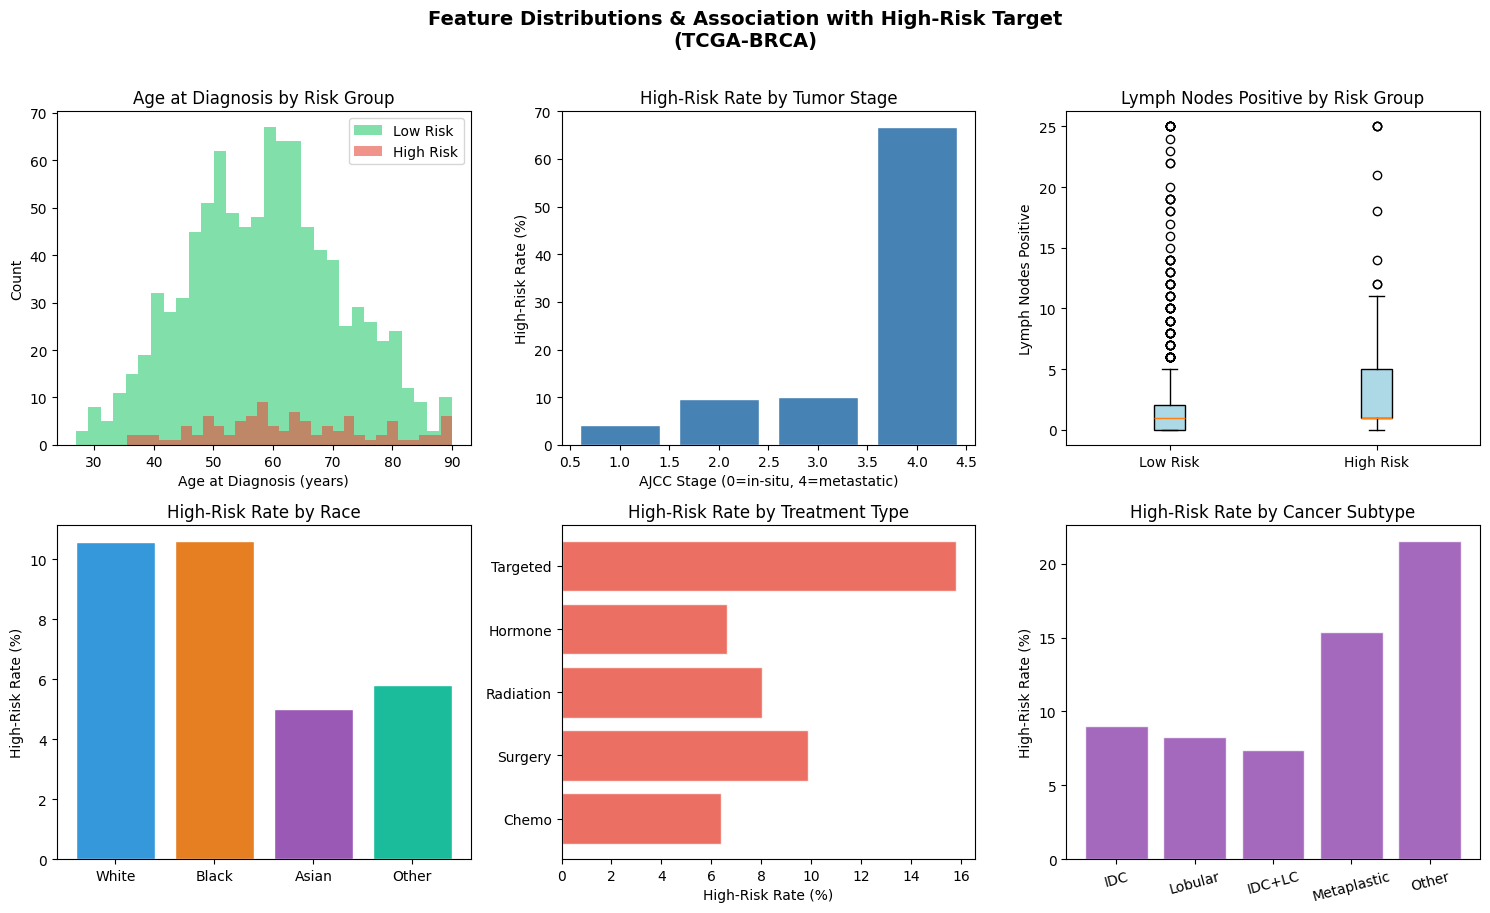

Plot saved to outputs/plots/feature_distributions.png


In [18]:
# --- Plot 1: Age distribution by risk group ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

high_risk = final_df[final_df['high_risk'] == 1]
low_risk  = final_df[final_df['high_risk'] == 0]

# Age
axes[0].hist(low_risk['age_at_diagnosis'],  bins=30, alpha=0.6, color='#2ecc71', label='Low Risk')
axes[0].hist(high_risk['age_at_diagnosis'], bins=30, alpha=0.6, color='#e74c3c', label='High Risk')
axes[0].set_xlabel('Age at Diagnosis (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age at Diagnosis by Risk Group')
axes[0].legend()

# Stage
stage_risk = final_df.groupby('stage_encoded')['high_risk'].mean() * 100
axes[1].bar(stage_risk.index, stage_risk.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('AJCC Stage (0=in-situ, 4=metastatic)')
axes[1].set_ylabel('High-Risk Rate (%)')
axes[1].set_title('High-Risk Rate by Tumor Stage')

# Lymph nodes
axes[2].boxplot(
    [low_risk['lymph_nodes_positive'].values, high_risk['lymph_nodes_positive'].values],
    labels=['Low Risk', 'High Risk'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
axes[2].set_ylabel('Lymph Nodes Positive')
axes[2].set_title('Lymph Nodes Positive by Risk Group')

# Race
race_cols = ['race_white', 'race_black', 'race_asian', 'race_other']
race_labels = ['White', 'Black', 'Asian', 'Other']
race_risk_rate = [final_df[final_df[c]==1]['high_risk'].mean()*100 for c in race_cols]
axes[3].bar(race_labels, race_risk_rate, color=['#3498db','#e67e22','#9b59b6','#1abc9c'], edgecolor='white')
axes[3].set_ylabel('High-Risk Rate (%)')
axes[3].set_title('High-Risk Rate by Race')

# Treatment
treat_cols_plot = ['treat_chemotherapy','treat_surgery','treat_radiation','treat_hormone','treat_targeted']
treat_labels = ['Chemo','Surgery','Radiation','Hormone','Targeted']
treat_risk = [final_df[final_df[c]==1]['high_risk'].mean()*100 for c in treat_cols_plot]
axes[4].barh(treat_labels, treat_risk, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[4].set_xlabel('High-Risk Rate (%)')
axes[4].set_title('High-Risk Rate by Treatment Type')

# Subtype
sub_cols = ['subtype_IDC','subtype_LC','subtype_IDC_LC','subtype_metaplastic','subtype_other_subtype']
sub_labels = ['IDC','Lobular','IDC+LC','Metaplastic','Other']
sub_risk = [final_df[final_df[c]==1]['high_risk'].mean()*100 for c in sub_cols]
axes[5].bar(sub_labels, sub_risk, color='#8e44ad', edgecolor='white', alpha=0.8)
axes[5].set_ylabel('High-Risk Rate (%)')
axes[5].set_title('High-Risk Rate by Cancer Subtype')
axes[5].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Distributions & Association with High-Risk Target\n(TCGA-BRCA)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/feature_distributions.png')

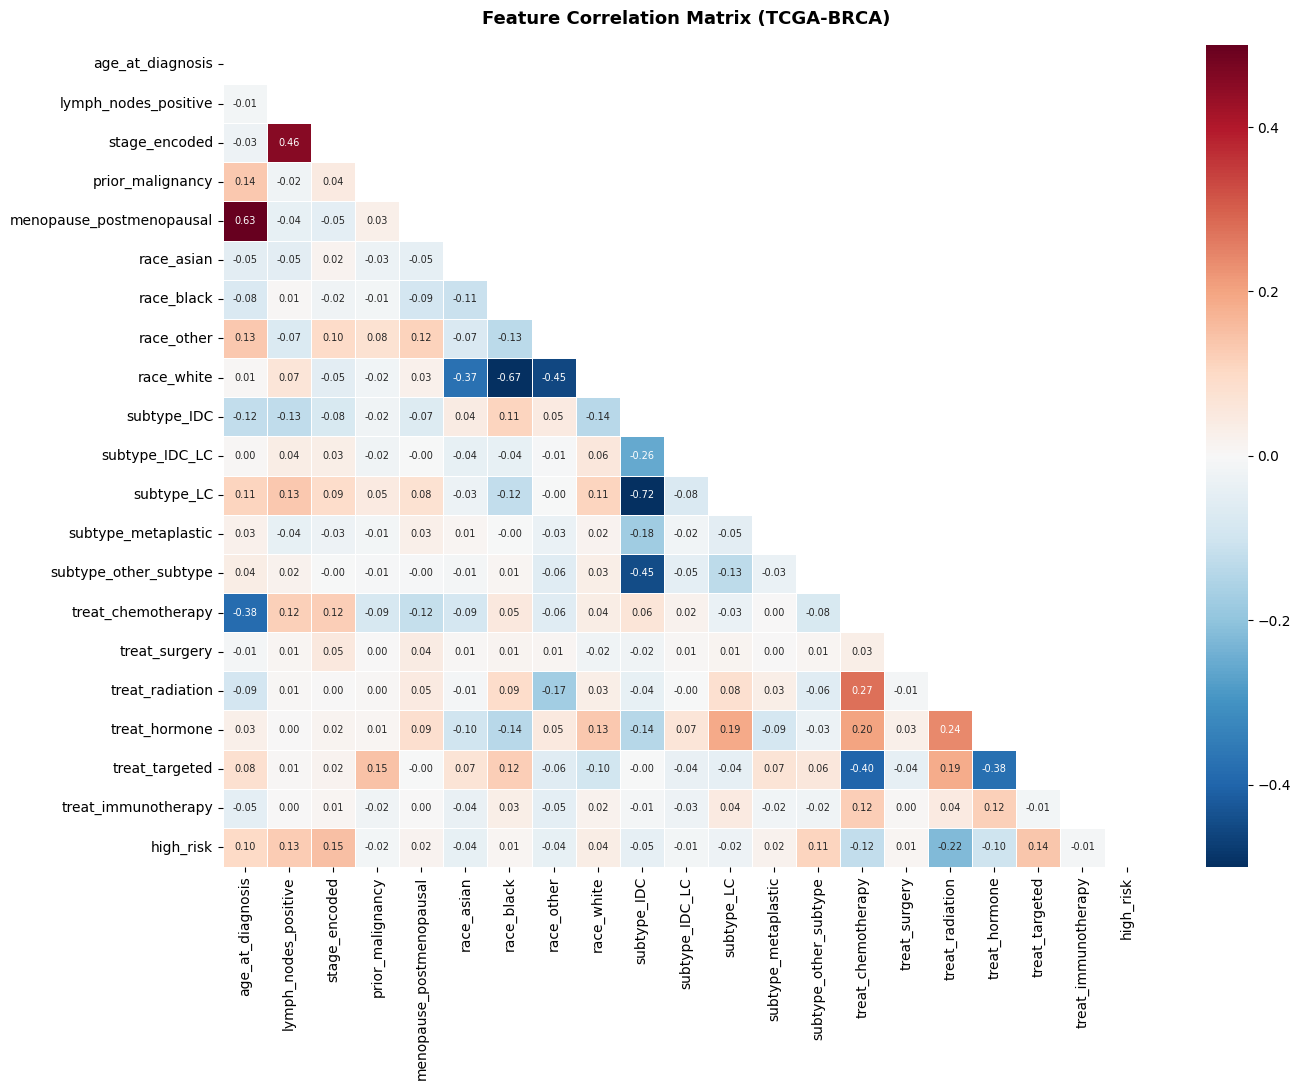

Plot saved to outputs/plots/correlation_heatmap.png


In [19]:
# --- Correlation heatmap of all features ---
fig, ax = plt.subplots(figsize=(14, 11))

corr_matrix = final_df[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Feature Correlation Matrix (TCGA-BRCA)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PLOT_DIR + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/plots/correlation_heatmap.png')

## 9. Export Processed Dataset

In [20]:
# Save the final processed file
output_path = PROC_DIR + 'brca_features.csv'
final_df.to_csv(output_path, index=False)

print('='*55)
print('  PREPROCESSING COMPLETE')
print('='*55)
print(f'  Output : {output_path}')
print(f'  Shape  : {final_df.shape[0]:,} patients × {final_df.shape[1]} columns')
print(f'  Features: {len(FEATURE_COLS)}')
print(f'  Target  : high_risk')
print(f'    High risk (1): {final_df["high_risk"].sum():,} patients ({final_df["high_risk"].mean()*100:.1f}%)')
print(f'    Low risk  (0): {(final_df["high_risk"]==0).sum():,} patients ({(1-final_df["high_risk"].mean())*100:.1f}%)')
print()
print('  Columns saved:')
for col in final_df.columns:
    print(f'    - {col}')

  PREPROCESSING COMPLETE
  Output : data/processed/brca_features.csv
  Shape  : 1,036 patients × 24 columns
  Features: 20
  Target  : high_risk
    High risk (1): 102 patients (9.8%)
    Low risk  (0): 934 patients (90.2%)

  Columns saved:
    - cases.case_id
    - age_at_diagnosis
    - lymph_nodes_positive
    - stage_encoded
    - prior_malignancy
    - menopause_postmenopausal
    - race_asian
    - race_black
    - race_other
    - race_white
    - subtype_IDC
    - subtype_IDC_LC
    - subtype_LC
    - subtype_metaplastic
    - subtype_other_subtype
    - treat_chemotherapy
    - treat_surgery
    - treat_radiation
    - treat_hormone
    - treat_targeted
    - treat_immunotherapy
    - survival_time
    - event
    - high_risk


In [21]:
# Final sanity check — preview of processed data
print('First 5 rows of processed dataset:')
final_df[FEATURE_COLS[:8] + [TARGET_COL]].head()

First 5 rows of processed dataset:


,age_at_diagnosis,lymph_nodes_positive,stage_encoded,prior_malignancy,menopause_postmenopausal,race_asian,race_black,race_other,high_risk
0,60.996578,0.0,1.0,0.0,1.0,0,0,0,0
1,70.726899,0.0,1.0,0.0,1.0,0,0,0,0
2,50.225873,1.0,2.0,0.0,0.0,0,0,0,0
3,56.709103,0.0,2.0,0.0,1.0,0,0,0,0
4,76.501027,1.0,4.0,0.0,1.0,0,0,1,0
